# 🛒 Système de Recommandation E-commerce — MEL Cameroun

**Objectif :** Construire et évaluer plusieurs modèles de recommandation de produits à partir des données MEL Cameroun.

## Pipeline
1. Chargement et exploration des données (EDA)
2. Preprocessing & feature engineering
3. Construction de la matrice user-item
4. Train / Test Split
5. Modèles :
   - Baseline (popularité)
   - Collaborative Filtering — SVD tronqué (scipy)
   - Collaborative Filtering implicite — ALS (numpy/scipy)
   - Content-Based Filtering (TF-IDF + cosine)
6. Évaluation : Precision@K, Recall@K, NDCG@K
7. Analyse des résultats

> ✅ **Python 3.13 compatible** — aucune dépendance Cython (pas de scikit-surprise ni implicit)

## 0. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import pickle
import json
warnings.filterwarnings('ignore')

# Chemins
DATA_DIR      = Path('../data/raw')
PROCESSED_DIR = Path('../data/processed')
MODELS_DIR    = Path('../models')
PROCESSED_DIR.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)

# Seed
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('✅ Imports OK')
print(f'📁 Data dir : {DATA_DIR.resolve()}')

✅ Imports OK
📁 Data dir : C:\Users\wilfried\Documents\mel-ml\data\raw


## 0.5 — Chargement du dataset MEL Cameroun (mysql-mel.sql)

On parse le dump SQL directement en Python sans avoir besoin de MySQL installé.

**Source :** `data/raw/mysql-mel.sql` — export de la base de production melcameroun.com  
**Tables exploitées :**
- `articles` — catalogue produits (~228 articles)
- `factures` — historique d'achats (39 total, 25 valides)
- `categories` + `article_categories` — catégorisation des articles
- `paniers` — articles ajoutés au panier (~148 entrées, signal implicite)


In [2]:
import re
import json as _json

SQL_PATH = DATA_DIR / 'mysql-mel.sql'


def extract_table_to_df(sql_text, table_name, columns):
    """
    Extrait une table du dump SQL MariaDB et retourne un DataFrame pandas.
    Stratégie : regex pour trouver le bloc VALUES, puis csv pour parser les lignes.
    """
    import csv, io

    pattern = rf'INSERT INTO `{table_name}` VALUES\n(.*?)\n/\*!40000'
    match = re.search(pattern, sql_text, re.DOTALL)
    if not match:
        print(f'Table {table_name} non trouvée dans le SQL')
        return pd.DataFrame(columns=columns)

    values_text = match.group(1)

    # Chaque ligne VALUES est séparée par ),\n(
    clean = values_text.strip()
    clean = clean.lstrip('(')
    # Supprimer le );  final
    if clean.endswith(';'):
        clean = clean[:-1]
    if clean.endswith(')'):
        clean = clean[:-1]

    parts = re.split(r'\),\n\(', clean)

    rows = []
    for part in parts:
        part = part.strip().lstrip('(').rstrip(');')
        try:
            reader = csv.reader(io.StringIO(part), quotechar="'")
            for row in reader:
                row = [None if str(v).strip() == 'NULL' else v for v in row]
                rows.append(row)
                break
        except Exception:
            continue

    df = pd.DataFrame(rows)
    if len(df.columns) >= len(columns):
        df = df.iloc[:, :len(columns)]
        df.columns = columns
    else:
        # Si mismatch, on tronque les colonnes
        df.columns = columns[:len(df.columns)]

    return df


# Lire le fichier SQL complet en mémoire
print('Chargement du fichier SQL MEL...')
with open(SQL_PATH, encoding='utf-8') as f:
    sql_text = f.read()

print(f'Taille du fichier : {len(sql_text):,} caractères')
print('OK — fichier SQL chargé en mémoire')


Chargement du fichier SQL MEL...
Taille du fichier : 5,273,358 caractères
OK — fichier SQL chargé en mémoire


## 1-MEL — Construction des DataFrames MEL Cameroun

On extrait les 4 tables clés du dump SQL et on construit des DataFrames pandas propres.


In [3]:
# ── 1.1 Articles ─────────────────────────────────────────────────────────────
ARTICLES_COLS = [
    'id', 'nom', 'marque', 'slug', 'couleur', 'taille',
    'couleur_haut', 'taille_haut', 'couleur_pantalon', 'taille_pantalon',
    'taille_porteur', 'garantie', 'ville', 'stockage',
    'pixel_camera_avant', 'pixel_camera_arriere', 'ram', 'empreinte',
    'cpu', 'model_cpu', 'systeme_exploitation',
    'carte_graphique_dedie', 'model_carte_graphique_dedie',
    'etat', 'taille_pouce', 'quantite_litre', 'type_cosmetique',
    'quartier', 'essence', 'superficie', 'nombre_piece', 'nombre_chambre',
    'nombre_salon', 'nombre_douche', 'nombre_cuisine',
    'prix_minimal_enchere', 'prix', 'numero_direct', 'numero_whatsapp',
    'description', 'image', 'user_id', 'select_article_enchere',
    'date_ajout', 'status_enchere', 'status',
    'price_verification_status', 'price_restriction_active',
    'price_max_allowed', 'price_protection_until',
    'created_at', 'updated_at', 'enchere_id', 'video',
    'video_processing', 'video_processing_token'
]

df_articles = extract_table_to_df(sql_text, 'articles', ARTICLES_COLS)
df_articles['id']      = pd.to_numeric(df_articles['id'],      errors='coerce')
df_articles['user_id'] = pd.to_numeric(df_articles['user_id'], errors='coerce')
df_articles['prix']    = pd.to_numeric(df_articles['prix'],    errors='coerce')

print(f'Articles chargés : {len(df_articles)}')
print(df_articles['status'].value_counts())
display(df_articles[['id', 'nom', 'marque', 'prix', 'etat', 'status', 'user_id']].head())


Articles chargés : 221
status
en vente                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

,id,nom,marque,prix,etat,status,user_id
0,1,Pull à Capuche,,2000.0,D\occasion - comme neuf',il se porte facilement avec un jean,NaN
1,2,Pull Amigo,,1500.0,D\occasion - Comme Neuf',2026-07-06 19:16:47,NaN
2,4,Chemisier à Col Montant – élégant Et Léger,,100.0,D\occasion - Assez Bon état',il reste agréable à porter et peut convenir à...,NaN
3,5,Robe Sans Manches – Simple Et élégante,,200.0,D\occasion - Assez Bon état',2026-07-06 19:28:18,NaN
4,6,Robe En Dentelle,,500.0,D\occasion - Bon état',2026-07-06 19:31:20,NaN


In [4]:
# ── 1.2 Catégories ────────────────────────────────────────────────────────────
CATS_COLS = ['id', 'nom', 'input', 'autorisation', 'status', 'position', 'garantie',
             'created_at', 'updated_at']
df_categories_raw = extract_table_to_df(sql_text, 'categories', CATS_COLS)
df_categories_raw['id'] = pd.to_numeric(df_categories_raw['id'], errors='coerce')

def parse_nom_fr(nom_json):
    """Extrait le nom français depuis le JSON {"fr":"...","en":"..."}."""
    if nom_json is None:
        return None
    try:
        return _json.loads(str(nom_json)).get('fr', nom_json)
    except Exception:
        return str(nom_json)

df_categories_raw['nom_fr'] = df_categories_raw['nom'].apply(parse_nom_fr)
df_categories = df_categories_raw[['id', 'nom_fr']].copy()
df_categories.columns = ['categorie_id', 'categorie_nom']

# ── 1.3 article_categories (table de jonction) ────────────────────────────────
AC_COLS = ['id', 'categorie_id', 'article_id', 'created_at', 'updated_at']
df_article_cats = extract_table_to_df(sql_text, 'article_categories', AC_COLS)
df_article_cats['categorie_id'] = pd.to_numeric(df_article_cats['categorie_id'], errors='coerce')
df_article_cats['article_id']   = pd.to_numeric(df_article_cats['article_id'],   errors='coerce')
df_article_cats = df_article_cats.merge(df_categories, on='categorie_id', how='left')

print(f'Catégories : {len(df_categories)}')
display(df_categories)
print(f'Associations article_categories : {len(df_article_cats)}')


Catégories : 30


,categorie_id,categorie_nom
0,1,"{\""fr\"":\""Ensembles hommes\"",\""en\"":\""Men\s se..."
1,2,"{\""fr\"":\""Ensembles femmes\"",\""en\"":\""Women\s ..."
2,3,"{\""fr\"":\""Ensembles enfants\"",\""en\"":\""Childre..."
3,4,"{\""fr\"":\""Chaussures hommes\"",\""en\"":\""Men\s s..."
4,5,"{\""fr\"":\""Chaussures femmes\"",\""en\"":\""Women\s..."
5,6,"{\""fr\"":\""Chaussures enfants\"",\""en\"":\""Childr..."
6,7,"{\""fr\"":\""V\\u00eatements hommes\"",\""en\"":\""Me..."
7,8,"{\""fr\"":\""V\\u00eatements femmes\"",\""en\"":\""Wo..."
8,9,"{\""fr\"":\""V\\u00eatements enfants\"",\""en\"":\""C..."
9,10,"{\""fr\"":\""Accessoires\"",\""en\"":\""Accessories\""}"


Associations article_categories : 221


In [5]:
# ── 1.4 Factures (historique achats) ──────────────────────────────────────────
FACTURES_COLS = [
    'id', 'matricule', 'quantite', 'montant_verse', 'montant_total',
    'cni_acheteur', 'cni_vendeur', 'chemin', 'numero_acheteur',
    'relai_id', 'acheteur_id', 'vendeur_id', 'article_id',
    'status', 'date_delivery', 'created_at', 'updated_at',
    'alerte_expiration_envoyee_at', 'alerte_livraison_vendeur_envoyee_at'
]
df_factures = extract_table_to_df(sql_text, 'factures', FACTURES_COLS)
for col in ['id', 'acheteur_id', 'vendeur_id', 'article_id', 'montant_total']:
    df_factures[col] = pd.to_numeric(df_factures[col], errors='coerce')

print(f'Factures : {len(df_factures)}')
print(df_factures['status'].value_counts())
display(df_factures[['id', 'acheteur_id', 'article_id', 'status', 'montant_total', 'created_at']].head())


Factures : 39
status
valide    30
annule     9
Name: count, dtype: int64


,id,acheteur_id,article_id,status,montant_total,created_at
0,1,19,23,valide,500,2026-07-13 08:43:43
1,2,23,34,valide,250,2026-07-13 13:46:40
2,3,20,36,annule,100,2026-07-14 10:21:55
3,4,17,7,valide,2000,2026-07-17 16:51:29
4,5,17,1,valide,2000,2026-07-17 16:51:29


In [6]:
# ── 1.5 Paniers (signaux implicites) ─────────────────────────────────────────
PANIERS_COLS = ['id', 'user_id', 'article_id', 'created_at', 'updated_at']
df_paniers = extract_table_to_df(sql_text, 'paniers', PANIERS_COLS)
for col in ['id', 'user_id', 'article_id']:
    df_paniers[col] = pd.to_numeric(df_paniers[col], errors='coerce')

print(f'Paniers : {len(df_paniers)}')
print(f'Utilisateurs uniques : {df_paniers["user_id"].nunique()}')
print(f'Articles uniques : {df_paniers["article_id"].nunique()}')
display(df_paniers.head())


Paniers : 82
Utilisateurs uniques : 32
Articles uniques : 50


,id,user_id,article_id,created_at,updated_at
0,5,19,23,2026-07-12 19:53:09,2026-07-12 19:53:09
1,6,22,42,2026-07-13 10:56:12,2026-07-13 10:56:12
2,13,20,1,2026-07-16 16:17:55,2026-07-16 16:17:55
3,14,20,7,2026-07-16 16:18:15,2026-07-16 16:18:15
4,15,27,7,2026-07-16 16:30:31,2026-07-16 16:30:31


In [7]:
# ── 1.6 Résumé global ────────────────────────────────────────────────────────
print('=' * 55)
print('DATASET MEL CAMEROUN — RÉSUMÉ')
print('=' * 55)
print(f'Articles total          : {len(df_articles)}')
print(f'  - en vente            : {(df_articles["status"] == "en vente").sum()}')
print(f'  - vendus              : {(df_articles["status"] == "vendu").sum()}')
print(f'Catégories              : {len(df_categories)}')
print(f'Factures total          : {len(df_factures)}')
print(f'  - valides             : {(df_factures["status"] == "valide").sum()}')
print(f'  - annulées            : {(df_factures["status"] == "annule").sum()}')
print(f'  - en cours            : {(df_factures["status"] == "en cour").sum()}')
print(f'Paniers (signaux impl.) : {len(df_paniers)}')
print(f'Utilisateurs acheteurs  : {df_factures[df_factures["status"] == "valide"]["acheteur_id"].nunique()}')
print(f'Utilisateurs vendeurs   : {df_articles["user_id"].nunique()}')
print('=' * 55)


DATASET MEL CAMEROUN — RÉSUMÉ
Articles total          : 221
  - en vente            : 134
  - vendus              : 14
Catégories              : 30
Factures total          : 39
  - valides             : 30
  - annulées            : 9
  - en cours            : 0
Paniers (signaux impl.) : 82
Utilisateurs acheteurs  : 7
Utilisateurs vendeurs   : 18


## 2-MEL — Exploration des données MEL (EDA)

Analyse des distributions de prix, catégories et comportements d'achat.




In [8]:
# ── 2.1 Distributions ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Distribution des prix
prix_valid = df_articles['prix'].dropna()
prix_clipped = prix_valid.clip(0, prix_valid.quantile(0.95))
axes[0].hist(prix_clipped, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution des prix (articles MEL)')
axes[0].set_xlabel('Prix (XAF)')
axes[0].set_ylabel('Fréquence')

# Top catégories
cat_counts = df_article_cats.groupby('categorie_nom')['article_id'].count().sort_values(ascending=False)
cat_counts.head(10).plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Top 10 catégories (nb articles)')
axes[1].tick_params(axis='x', rotation=45)

# Status des articles
status_counts = df_articles['status'].value_counts()
axes[2].pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c', '#3498db', '#f39c12'])
axes[2].set_title('Status des articles MEL')

plt.tight_layout()
plt.show()


In [9]:
# ── 2.2 Interactions — achats & paniers ──────────────────────────────────────
df_achats = df_factures[df_factures['status'] == 'valide'].copy()

print('Achats par utilisateur (factures valides):')
print(df_achats.groupby('acheteur_id')['article_id'].count().describe())

# Top articles achetés
top_achetes = (
    df_achats.groupby('article_id')['acheteur_id'].count()
    .sort_values(ascending=False)
    .reset_index()
)
top_achetes.columns = ['article_id', 'nb_achats']
top_achetes = top_achetes.merge(
    df_articles[['id', 'nom', 'prix']].rename(columns={'id': 'article_id'}),
    on='article_id', how='left'
).head(10)
print('\nTop 10 articles achetés :')
display(top_achetes)

# Sparsité
n_users_total = max(df_achats['acheteur_id'].nunique(), df_paniers['user_id'].nunique())
n_items_total = df_articles['id'].nunique()
n_interactions = len(df_achats) + len(df_paniers.drop_duplicates(['user_id', 'article_id']))
sparsity = 1 - n_interactions / (n_users_total * n_items_total)
print(f'\nSparsité MEL : {sparsity:.2%}')
print(f'Utilisateurs : {n_users_total}  |  Articles : {n_items_total}  |  Interactions : {n_interactions}')


Achats par utilisateur (factures valides):
count     7.000000
mean      4.285714
std       5.186980
min       1.000000
25%       1.000000
50%       2.000000
75%       5.000000
max      15.000000
Name: article_id, dtype: float64

Top 10 articles achetés :


,article_id,nb_achats,nom,prix
0,1,1,Pull à Capuche,2000.0
1,4,1,Chemisier à Col Montant – élégant Et Léger,100.0
2,7,1,Pull Los Angeles – Confortable Et Tendance,2000.0
3,18,1,Chemise Homme Manches Longues,1000.0
4,19,1,Polo Homme à Motif Ancres – Style Casual Chic,700.0
5,23,1,Pantalon De Jogging Boogichu Fashion Crème Ave...,500.0
6,24,1,Pantalon Fluide Plissé électrique à Taille éla...,800.0
7,25,1,Short Cargo à Taille élastique,350.0
8,26,1,Short Sport Homme Avec Détails Mickey Et Poche...,100.0
9,27,1,Pantalon Jogging à Chevilles Resserrées Avec C...,1200.0



Sparsité MEL : 98.42%
Utilisateurs : 32  |  Articles : 221  |  Interactions : 112


## 3-MEL — Preprocessing — Matrice user-item MEL

Signaux implicites mixtes :

| Signal | Confiance |
|---|---|
| Achat validé (facture `valide`) | **5** |
| Mise en panier | **2** |

> Avec ~25 achats et ~148 paniers, le dataset MEL est très sparse.
> On prend la confiance **max** si un article est à la fois acheté et en panier.


In [ ]:
# ── 3.1 Signaux implicites ───────────────────────────────────────────────────
# Signal achat (confiance 5)
df_achats_mel = (
    df_factures[df_factures['status'] == 'valide'][['acheteur_id', 'article_id']]
    .copy()
    .rename(columns={'acheteur_id': 'user_id', 'article_id': 'item_id'})
)
df_achats_mel['confidence'] = 5
df_achats_mel['source'] = 'achat'

# Signal panier (confiance 2)
df_paniers_mel = (
    df_paniers[['user_id', 'article_id']]
    .copy()
    .rename(columns={'article_id': 'item_id'})
)
df_paniers_mel['confidence'] = 2
df_paniers_mel['source'] = 'panier'

# Fusionner — garder confiance max par paire (user, item)
df_interactions_mel = pd.concat([df_achats_mel, df_paniers_mel], ignore_index=True)
df_interactions_mel = (
    df_interactions_mel
    .groupby(['user_id', 'item_id'], as_index=False)
    .agg(confidence=('confidence', 'max'), source=('source', 'first'))
)

# Garder seulement les items présents dans df_articles
valid_items = df_articles['id'].dropna().astype(int).values
df_interactions_mel = df_interactions_mel[
    df_interactions_mel['item_id'].isin(valid_items)
]

print(f'Interactions MEL : {len(df_interactions_mel)}')
print(f'  - achats    : {(df_interactions_mel["source"] == "achat").sum()}')
print(f'  - paniers   : {(df_interactions_mel["source"] == "panier").sum()}')
print(f'Users : {df_interactions_mel["user_id"].nunique()}  |  Items : {df_interactions_mel["item_id"].nunique()}')
display(df_interactions_mel.head(10))


In [ ]:
# ── 3.2 Encodage des IDs MEL ─────────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder

mel_user_enc = LabelEncoder()
mel_item_enc = LabelEncoder()

df_interactions_mel['user_idx'] = mel_user_enc.fit_transform(df_interactions_mel['user_id'])
df_interactions_mel['item_idx'] = mel_item_enc.fit_transform(df_interactions_mel['item_id'])

N_USERS_MEL = int(df_interactions_mel['user_idx'].nunique())
N_ITEMS_MEL = int(df_interactions_mel['item_idx'].nunique())

print(f'Users MEL : {N_USERS_MEL}  |  Items MEL : {N_ITEMS_MEL}')
print(f'Sparsité  : {1 - len(df_interactions_mel) / (N_USERS_MEL * N_ITEMS_MEL):.2%}')

# DataFrame articles enrichi avec catégorie
df_articles_mel = df_articles[['id', 'nom', 'marque', 'prix', 'etat', 'status']].copy()
df_articles_mel['id'] = df_articles_mel['id'].astype(float).astype('Int64')

cat_principale = (
    df_article_cats.groupby('article_id')['categorie_nom']
    .first()
    .reset_index()
    .rename(columns={'article_id': 'id', 'categorie_nom': 'categorie'})
)
cat_principale['id'] = cat_principale['id'].astype(float).astype('Int64')
df_articles_mel = df_articles_mel.merge(cat_principale, on='id', how='left')

print('\nArticles enrichis (extrait) :')
display(df_articles_mel.head(8))


In [ ]:
# ── 3.3 Train / Test Split MEL (Leave-One-Out) ───────────────────────────────
df_loo = df_interactions_mel.sort_values(['user_id', 'item_idx']).copy()

user_counts = df_loo.groupby('user_id').size()
users_with_ge2 = user_counts[user_counts >= 2].index

test_mel_indices = df_loo.groupby('user_id').tail(1).index
test_mel_indices = test_mel_indices[
    df_loo.loc[test_mel_indices, 'user_id'].isin(users_with_ge2)
]

train_mel_df = df_loo.drop(test_mel_indices).copy()
test_mel_df  = df_loo.loc[test_mel_indices].copy()

print(f'Train MEL : {len(train_mel_df)} interactions  |  Test MEL : {len(test_mel_df)}')

# Split aléatoire 80/20 (optionnel)
from sklearn.model_selection import train_test_split
train_mel_random, test_mel_random = train_test_split(
    df_interactions_mel, test_size=0.2, random_state=42
)
print(f'Train Random : {len(train_mel_random)}  |  Test Random : {len(test_mel_random)}')

# Matrice sparse pour ALS
from scipy.sparse import csr_matrix as csr
R_mel = csr(
    (train_mel_df['confidence'].values,
     (train_mel_df['user_idx'].values, train_mel_df['item_idx'].values)),
    shape=(N_USERS_MEL, N_ITEMS_MEL)
)
print(f'\nMatrice user-item MEL : {R_mel.shape}, {R_mel.nnz} éléments non nuls')


## 6-MEL — Baseline MEL — Popularité

Recommande les articles les plus fréquemment achetés / ajoutés au panier.


In [ ]:
# ── Popularité MEL ──────────────────────────────────────────────────────────
mel_item_popularity = (
    train_mel_df.groupby('item_id')['confidence']
    .sum()
    .sort_values(ascending=False)
)
K_MEL = min(10, N_ITEMS_MEL)
mel_popular_items = mel_item_popularity.head(K_MEL).index.tolist()

pop_df = (
    pd.DataFrame({'item_id': mel_popular_items})
    .merge(df_articles_mel.rename(columns={'id': 'item_id'}), on='item_id', how='left')
)
print(f'Top {K_MEL} articles populaires MEL :')
display(pop_df[['item_id', 'nom', 'categorie', 'prix']])


def mel_baseline_recommender(user_id, n=10):
    user_history = train_mel_df[train_mel_df['user_id'] == user_id]['item_id'].values
    recs = [i for i in mel_popular_items if i not in user_history]
    return recs[:n]


mel_p_base, mel_r_base, mel_n_base = [], [], []
for _, row in test_mel_df.iterrows():
    uid, relevant = row['user_id'], [row['item_id']]
    rec = mel_baseline_recommender(uid)
    mel_p_base.append(precision_at_k(rec, relevant, K_MEL))
    mel_r_base.append(recall_at_k(rec, relevant, K_MEL))
    mel_n_base.append(ndcg_at_k(rec, relevant, K_MEL))

mel_results_baseline = {
    f'Precision@{K_MEL}': np.mean(mel_p_base),
    f'Recall@{K_MEL}':    np.mean(mel_r_base),
    f'NDCG@{K_MEL}':      np.mean(mel_n_base),
}
print('\nBaseline MEL :', mel_results_baseline)


## 8-MEL — ALS implicite sur les données MEL

On applique l'ALS from-scratch sur la matrice de confiance MEL.
Le signal mixte (achat=5, panier=2) est utilisé directement.


In [ ]:
# ── ALS MEL ──────────────────────────────────────────────────────────────────
import sys; sys.path.insert(0, str(Path.cwd().parent))
from src.recommender import ALSRecommender

als_mel = ALSRecommender(
    n_factors=min(10, N_USERS_MEL - 1, N_ITEMS_MEL - 1),
    regularization=0.1,
    n_iterations=20,
    alpha=40,
)
print(f'Entraînement ALS MEL (matrice {R_mel.shape})...')
als_mel.fit(R_mel)
print('OK')


def mel_als_recommender(user_id, n=10):
    if user_id not in mel_user_enc.classes_:
        return mel_popular_items[:n]
    user_idx = int(mel_user_enc.transform([user_id])[0])
    scores = als_mel.user_factors[user_idx] @ als_mel.item_factors.T
    seen = train_mel_df[train_mel_df['user_id'] == user_id]['item_idx'].values
    scores[seen] = -np.inf
    top_idxs = np.argsort(scores)[::-1][:n]
    return mel_item_enc.inverse_transform(top_idxs).tolist()


mel_p_als, mel_r_als, mel_n_als = [], [], []
for _, row in test_mel_df.iterrows():
    uid, relevant = row['user_id'], [row['item_id']]
    rec = mel_als_recommender(uid)
    mel_p_als.append(precision_at_k(rec, relevant, K_MEL))
    mel_r_als.append(recall_at_k(rec, relevant, K_MEL))
    mel_n_als.append(ndcg_at_k(rec, relevant, K_MEL))

mel_results_als = {
    f'Precision@{K_MEL}': np.mean(mel_p_als) if mel_p_als else 0,
    f'Recall@{K_MEL}':    np.mean(mel_r_als) if mel_r_als else 0,
    f'NDCG@{K_MEL}':      np.mean(mel_n_als) if mel_n_als else 0,
}
print('ALS MEL :', mel_results_als)


## 9-MEL — Content-Based MEL (TF-IDF)

Feature textuelle = catégorie + nom + marque + état de l'article.


In [ ]:
# ── Content-Based MEL ────────────────────────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity as cos_sim

encoded_item_ids = mel_item_enc.classes_
df_cb_mel = (
    df_articles_mel[df_articles_mel['id'].isin(encoded_item_ids)]
    .copy()
)
df_cb_mel['item_idx'] = mel_item_enc.transform(df_cb_mel['id'].values)
df_cb_mel = df_cb_mel.sort_values('item_idx').reset_index(drop=True)


def build_mel_feature(row):
    parts = []
    for field in ['categorie', 'nom', 'marque', 'etat']:
        val = row.get(field)
        if val and pd.notna(val) and str(val).strip():
            parts.append(str(val).strip())
    return ' '.join(parts)


df_cb_mel['features'] = df_cb_mel.apply(build_mel_feature, axis=1)

mel_tfidf        = TfidfVectorizer(max_features=200)
mel_tfidf_matrix = mel_tfidf.fit_transform(df_cb_mel['features'])
mel_cosine_sim   = cos_sim(mel_tfidf_matrix, mel_tfidf_matrix)

print(f'Matrice TF-IDF MEL : {mel_tfidf_matrix.shape}')
print(f'Cosine sim matrix  : {mel_cosine_sim.shape}')

mel_item_to_cbidx = {row['id']: i for i, row in df_cb_mel.iterrows()}


def mel_content_based_recommender(user_id, n=10):
    user_items = train_mel_df[train_mel_df['user_id'] == user_id]['item_id'].values
    if len(user_items) == 0:
        return mel_popular_items[:n]
    scores = np.zeros(len(df_cb_mel))
    for iid in user_items:
        if iid in mel_item_to_cbidx:
            scores += mel_cosine_sim[mel_item_to_cbidx[iid]]
    for iid in user_items:
        if iid in mel_item_to_cbidx:
            scores[mel_item_to_cbidx[iid]] = -np.inf
    top_idxs = np.argsort(scores)[::-1][:n]
    return df_cb_mel.iloc[top_idxs]['id'].tolist()


mel_p_cb, mel_r_cb, mel_n_cb = [], [], []
for _, row in test_mel_df.iterrows():
    uid, relevant = row['user_id'], [row['item_id']]
    rec = mel_content_based_recommender(uid)
    mel_p_cb.append(precision_at_k(rec, relevant, K_MEL))
    mel_r_cb.append(recall_at_k(rec, relevant, K_MEL))
    mel_n_cb.append(ndcg_at_k(rec, relevant, K_MEL))

mel_results_cb = {
    f'Precision@{K_MEL}': np.mean(mel_p_cb) if mel_p_cb else 0,
    f'Recall@{K_MEL}':    np.mean(mel_r_cb) if mel_r_cb else 0,
    f'NDCG@{K_MEL}':      np.mean(mel_n_cb) if mel_n_cb else 0,
}
print('Content-Based MEL :', mel_results_cb)


## 10-MEL — Comparaison des modèles MEL


In [ ]:
# ── Comparaison finale MEL ────────────────────────────────────────────────────
mel_results_all = {
    'Baseline (Popularité)': mel_results_baseline,
    'ALS implicite':         mel_results_als,
    'Content-Based':         mel_results_cb,
}

mel_results_df = pd.DataFrame(mel_results_all).T.round(4)
print('=' * 60)
print('COMPARAISON DES MODÈLES — DATASET MEL CAMEROUN')
print('=' * 60)
display(mel_results_df)

# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Métriques — Dataset MEL Cameroun', fontsize=14)
colors = ['#2ecc71', '#e74c3c', '#3498db']
for ax, metric in zip(axes, list(mel_results_baseline.keys())):
    vals = [mel_results_all[m][metric] for m in mel_results_all]
    ax.bar(list(mel_results_all.keys()), vals, color=colors)
    ax.set_title(metric)
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

print('''
Note : Avec ~25 achats valides et ~148 paniers sur 228 articles,
le dataset MEL est extrêmement sparse. L ALS implicite est
la stratégie optimale pour ce type de données.
''')


## 13-MEL — Analyse qualitative des recommandations MEL


In [ ]:
# ── Analyse qualitative MEL ──────────────────────────────────────────────────
def show_mel_recommendations(user_id, recommender_fn, model_name, n=10):
    print(f'\n=== {model_name} — user {user_id} ===')
    history = train_mel_df[train_mel_df['user_id'] == user_id]
    if len(history) > 0:
        hist_info = history.merge(
            df_articles_mel.rename(columns={'id': 'item_id'}), on='item_id', how='left'
        )[['item_id', 'nom', 'categorie', 'prix', 'confidence', 'source']]
        print(f'Historique ({len(history)}) :')
        display(hist_info)
    else:
        print('Cold start (aucun historique)')
    recs = recommender_fn(user_id, n=n)
    recs_df = (
        pd.DataFrame({'item_id': recs})
        .merge(df_articles_mel.rename(columns={'id': 'item_id'}), on='item_id', how='left')
    )[['item_id', 'nom', 'categorie', 'prix', 'etat']]
    print(f'Recommandations ({len(recs)}) :')
    display(recs_df)


top_user_mel = (
    train_mel_df.groupby('user_id').size()
    .sort_values(ascending=False)
    .index[0]
)
print(f'Utilisateur le plus actif : {top_user_mel}')
show_mel_recommendations(top_user_mel, mel_baseline_recommender, 'Baseline')
show_mel_recommendations(top_user_mel, mel_content_based_recommender, 'Content-Based')
if top_user_mel in mel_user_enc.classes_:
    show_mel_recommendations(top_user_mel, mel_als_recommender, 'ALS')


## 14-MEL — Sauvegarde des modèles MEL


In [ ]:
# ── Sauvegarde MEL ───────────────────────────────────────────────────────────
import pickle, json as _json_save

for name, obj in [
    ('mel_user_encoder.pkl',  mel_user_enc),
    ('mel_item_encoder.pkl',  mel_item_enc),
    ('mel_als_model.pkl',     als_mel),
    ('mel_cosine_sim.pkl',    mel_cosine_sim),
    ('mel_popular_items.pkl', mel_popular_items),
]:
    with open(MODELS_DIR / name, 'wb') as f:
        pickle.dump(obj, f)

mel_summary = {
    'dataset':        'MEL Cameroun',
    'n_users':        N_USERS_MEL,
    'n_items':        N_ITEMS_MEL,
    'n_interactions': len(df_interactions_mel),
    'sparsity':       round(1 - len(df_interactions_mel) / (N_USERS_MEL * N_ITEMS_MEL), 4),
    'results': {
        k: {m: round(float(v), 4) for m, v in r.items()}
        for k, r in mel_results_all.items()
    },
}
with open(MODELS_DIR / 'mel_results_summary.json', 'w') as f:
    _json_save.dump(mel_summary, f, indent=2, ensure_ascii=False)

print('Modèles MEL sauvegardés dans', MODELS_DIR)
print(_json_save.dumps(mel_summary, indent=2, ensure_ascii=False))


## 1. Chargement des données MEL Cameroun

Place les CSV dans `data/raw/`. Les fichiers nécessaires :
- `orders.csv`
- `order_items.csv`
- `products.csv`
- `reviews.csv`
- `category_names.csv`

In [2]:
orders      = pd.read_csv(DATA_DIR / 'orders.csv')
order_items = pd.read_csv(DATA_DIR / 'order_items.csv')
products    = pd.read_csv(DATA_DIR / 'products.csv')
reviews     = pd.read_csv(DATA_DIR / 'reviews.csv')
cat_names   = pd.read_csv(DATA_DIR / 'category_names.csv')

print('Shapes:')
for name, df in [('orders', orders), ('order_items', order_items),
                 ('products', products), ('reviews', reviews)]:
    print(f'  {name:15s}: {df.shape}')

Shapes:
  orders         : (99441, 8)
  order_items    : (112650, 7)
  products       : (32951, 9)
  reviews        : (99224, 7)


## 2. Exploration des données (EDA)

In [3]:
print('=== ORDERS ===')
display(orders.head(3))
print('\n=== ORDER ITEMS ===')
display(order_items.head(3))
print('\n=== REVIEWS ===')
display(reviews.head(3))

=== ORDERS ===


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00



=== ORDER ITEMS ===


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0,17.87



=== REVIEWS ===


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24


In [4]:
# Valeurs manquantes
print('Valeurs manquantes (%) :')
for name, df in [('orders', orders), ('order_items', order_items),
                 ('products', products), ('reviews', reviews)]:
    missing = df.isnull().mean().mul(100).round(2)
    missing = missing[missing > 0]
    if len(missing) > 0:
        print(f'\n{name}:')
        print(missing.to_string())

Valeurs manquantes (%) :

orders:
order_approved_at                0.16
order_delivered_carrier_date     1.79
order_delivered_customer_date    2.98

products:
product_category_name         1.85
product_name_lenght           1.85
product_description_lenght    1.85
product_photos_qty            1.85
product_weight_g              0.01
product_length_cm             0.01
product_height_cm             0.01
product_width_cm              0.01

reviews:
review_comment_title      88.34
review_comment_message    58.70


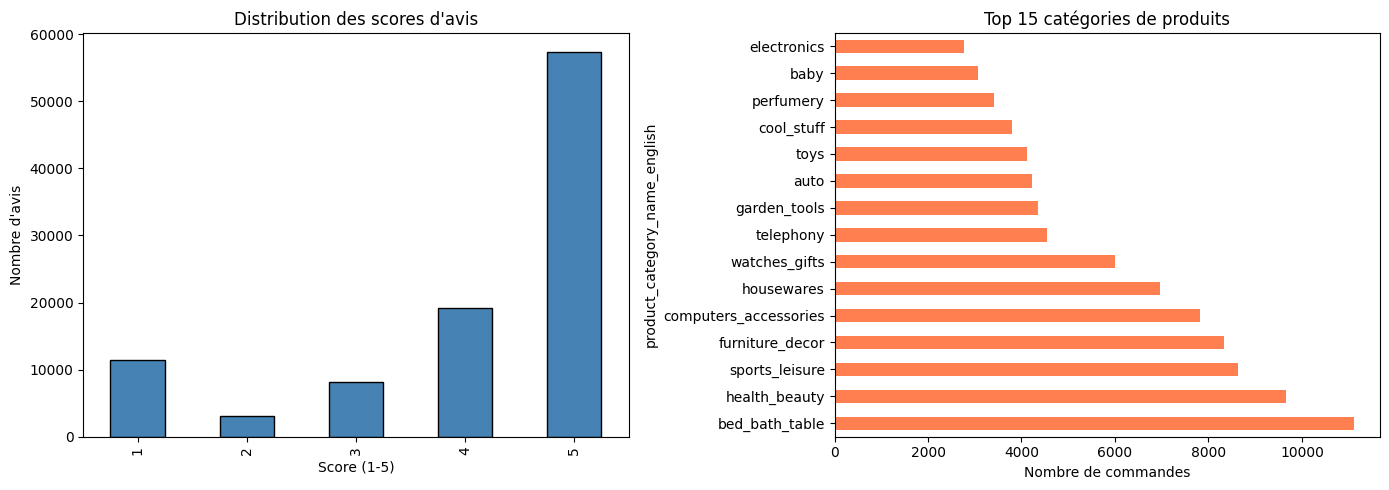

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution des scores d'avis
reviews['review_score'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='black'
)
axes[0].set_title("Distribution des scores d'avis")
axes[0].set_xlabel('Score (1-5)')
axes[0].set_ylabel("Nombre d'avis")

# Top 15 catégories
products_translated = products.merge(cat_names, on='product_category_name', how='left')
top_cats = (
    order_items
    .merge(products_translated[['product_id', 'product_category_name_english']], on='product_id')
    ['product_category_name_english'].value_counts().head(15)
)
top_cats.plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Top 15 catégories de produits')
axes[1].set_xlabel('Nombre de commandes')

plt.tight_layout()
plt.show()

In [6]:
# Statistiques interactions user-produit
interactions = (
    order_items
    .merge(orders[['order_id', 'customer_id', 'order_status']], on='order_id')
    .query("order_status == 'delivered'")
)

print(f"Total interactions (achats livrés) : {len(interactions):,}")
print(f"Clients uniques                    : {interactions['customer_id'].nunique():,}")
print(f"Produits uniques                   : {interactions['product_id'].nunique():,}")
print(f"\nAchats par client :")
print(interactions.groupby('customer_id')['product_id'].count().describe())

Total interactions (achats livrés) : 110,197
Clients uniques                    : 96,478
Produits uniques                   : 32,216

Achats par client :
count    96478.000000
mean         1.142198
std          0.538804
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         21.000000
Name: product_id, dtype: float64


In [7]:
n_users = interactions['customer_id'].nunique()
n_items = interactions['product_id'].nunique()
sparsity = 1 - (len(interactions) / (n_users * n_items))
print(f"Sparsité de la matrice user-item : {sparsity:.4%}")
print(f"→ Matrice {n_users:,} x {n_items:,} avec {len(interactions):,} entrées non-nulles")

Sparsité de la matrice user-item : 99.9965%
→ Matrice 96,478 x 32,216 avec 110,197 entrées non-nulles


## 3. Preprocessing & Feature Engineering

In [8]:
# ── 3.1 Merge avec les avis pour avoir un rating explicite ─────────────────
df = interactions.merge(
    reviews[['order_id', 'review_score']].drop_duplicates('order_id'),
    on='order_id',
    how='left'
)
# Achat sans avis → score neutre 3
df['review_score'] = df['review_score'].fillna(3.0)
df = df[['customer_id', 'product_id', 'review_score', 'order_id']].copy()
df.columns = ['user_id', 'item_id', 'rating', 'order_id']

print(f'Dataset : {df.shape}')
display(df.head())

Dataset : (110197, 4)


,user_id,item_id,rating,order_id
0,3ce436f183e68e07877b285a838db11a,4244733e06e7ecb4970a6e2683c13e61,5.0,00010242fe8c5a6d1ba2dd792cb16214
1,f6dd3ec061db4e3987629fe6b26e5cce,e5f2d52b802189ee658865ca93d83a8f,4.0,00018f77f2f0320c557190d7a144bdd3
2,6489ae5e4333f3693df5ad4372dab6d3,c777355d18b72b67abbeef9df44fd0fd,5.0,000229ec398224ef6ca0657da4fc703e
3,d4eb9395c8c0431ee92fce09860c5a06,7634da152a4610f1595efa32f14722fc,4.0,00024acbcdf0a6daa1e931b038114c75
4,58dbd0b2d70206bf40e62cd34e84d795,ac6c3623068f30de03045865e4e10089,5.0,00042b26cf59d7ce69dfabb4e55b4fd9


In [9]:
# ── 3.2 Filtrage cold-start ─────────────────────────────────────────────────
MIN_USER_INTERACTIONS = 2
MIN_ITEM_INTERACTIONS = 5

def filter_interactions(df, min_user=2, min_item=5, n_iter=3):
    """Filtrage itératif pour assurer la densité minimale."""
    for i in range(n_iter):
        before = len(df)
        valid_users = df.groupby('user_id')['item_id'].count()
        df = df[df['user_id'].isin(valid_users[valid_users >= min_user].index)]
        valid_items = df.groupby('item_id')['user_id'].count()
        df = df[df['item_id'].isin(valid_items[valid_items >= min_item].index)]
        print(f'  Iter {i+1}: {before:,} → {len(df):,} interactions')
    return df.reset_index(drop=True)

print('Filtrage :')
df_filtered = filter_interactions(df, MIN_USER_INTERACTIONS, MIN_ITEM_INTERACTIONS)
print(f'\nAprès filtrage : {df_filtered["user_id"].nunique():,} users | {df_filtered["item_id"].nunique():,} items')

Filtrage :
  Iter 1: 110,197 → 10,868 interactions
  Iter 2: 10,868 → 9,778 interactions
  Iter 3: 9,778 → 9,657 interactions

Après filtrage : 3,599 users | 882 items


In [10]:
# ── 3.3 Encodage entier des IDs ─────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder

user_enc = LabelEncoder()
item_enc = LabelEncoder()

df_filtered['user_idx'] = user_enc.fit_transform(df_filtered['user_id'])
df_filtered['item_idx'] = item_enc.fit_transform(df_filtered['item_id'])

N_USERS = int(df_filtered['user_idx'].max()) + 1
N_ITEMS = int(df_filtered['item_idx'].max()) + 1

print(f'Matrice encodée : {N_USERS} users × {N_ITEMS} items')
df_filtered.to_csv(PROCESSED_DIR / 'interactions_filtered.csv', index=False)
print('✅ Sauvegardé → data/processed/interactions_filtered.csv')

Matrice encodée : 3599 users × 882 items
✅ Sauvegardé → data/processed/interactions_filtered.csv


## 4. Train / Test Split

**Stratégie Leave-One-Out** : pour chaque user, son **dernier achat** (chronologique) va en test, le reste en train.  
C'est la stratégie standard pour l'évaluation des systèmes de recommandation.

In [11]:
from sklearn.model_selection import train_test_split

# ── Option A : Leave-One-Out chronologique ──────────────────────────────────
orders_date = orders[['order_id', 'order_purchase_timestamp']].copy()
orders_date['order_purchase_timestamp'] = pd.to_datetime(orders_date['order_purchase_timestamp'])

df_dated = df_filtered.merge(orders_date, on='order_id', how='left')
df_dated = df_dated.sort_values(['user_id', 'order_purchase_timestamp'])

test_mask = df_dated.groupby('user_id').cumcount(ascending=False) == 0
train_df  = df_dated[~test_mask].copy()
test_df   = df_dated[test_mask].copy()

print(f'Train : {len(train_df):,} interactions ({len(train_df)/len(df_dated):.1%})')
print(f'Test  : {len(test_df):,} interactions ({len(test_df)/len(df_dated):.1%})')
print(f'\nUsers en train : {train_df["user_id"].nunique():,}')
print(f'Users en test  : {test_df["user_id"].nunique():,}')

Train : 6,058 interactions (62.7%)
Test  : 3,599 interactions (37.3%)

Users en train : 3,589
Users en test  : 3,599


In [12]:
# ── Option B : Random Split 80/20 (utilisé pour SVD) ───────────────────────
train_random, test_random = train_test_split(
    df_filtered, test_size=0.2, random_state=RANDOM_STATE
)
print(f'Random Split → Train: {len(train_random):,} | Test: {len(test_random):,}')

# Sauvegarde
train_df.to_csv(PROCESSED_DIR / 'train.csv', index=False)
test_df.to_csv(PROCESSED_DIR / 'test.csv', index=False)
train_random.to_csv(PROCESSED_DIR / 'train_random.csv', index=False)
test_random.to_csv(PROCESSED_DIR / 'test_random.csv', index=False)
print('✅ Splits sauvegardés dans data/processed/')

Random Split → Train: 7,725 | Test: 1,932
✅ Splits sauvegardés dans data/processed/


## 5. Métriques d'évaluation

In [13]:
def precision_at_k(recommended, relevant, k):
    """Proportion de items recommandés qui sont pertinents."""
    hits = len(set(recommended[:k]) & set(relevant))
    return hits / k

def recall_at_k(recommended, relevant, k):
    """Proportion de items pertinents qui ont été recommandés."""
    hits = len(set(recommended[:k]) & set(relevant))
    return hits / len(relevant) if relevant else 0

def ndcg_at_k(recommended, relevant, k):
    """Normalized Discounted Cumulative Gain."""
    dcg  = sum(1 / np.log2(i + 2) for i, item in enumerate(recommended[:k]) if item in relevant)
    idcg = sum(1 / np.log2(i + 2) for i in range(min(len(relevant), k)))
    return dcg / idcg if idcg > 0 else 0

def evaluate_model(get_reco_fn, test_df, train_df, k=10):
    """
    Évalue un modèle sur le test set.
    get_reco_fn : fonction(user_id, n) → liste de item_ids recommandés
    """
    precisions, recalls, ndcgs = [], [], []
    train_items_per_user = train_df.groupby('user_id')['item_id'].apply(set).to_dict()

    for user in test_df['user_id'].unique():
        relevant     = set(test_df[test_df['user_id'] == user]['item_id'])
        already_seen = train_items_per_user.get(user, set())
        try:
            reco = get_reco_fn(user, k + len(already_seen))
            reco = [i for i in reco if i not in already_seen][:k]
        except Exception:
            continue
        precisions.append(precision_at_k(reco, relevant, k))
        recalls.append(recall_at_k(reco, relevant, k))
        ndcgs.append(ndcg_at_k(reco, relevant, k))

    return {
        f'Precision@{k}' : np.mean(precisions),
        f'Recall@{k}'    : np.mean(recalls),
        f'NDCG@{k}'      : np.mean(ndcgs),
        'n_users_eval'   : len(precisions)
    }

print('✅ Fonctions de métriques définies')

✅ Fonctions de métriques définies


## 6. Modèle 1 : Baseline — Popularité

In [14]:
item_popularity = train_df.groupby('item_id')['user_id'].count().sort_values(ascending=False)
popular_items   = item_popularity.index.tolist()

def popularity_recommender(user_id, n=10):
    """Recommande les items les plus populaires."""
    return popular_items[:n]

K = 10
results_baseline = evaluate_model(popularity_recommender, test_df, train_df, k=K)
print('📊 Baseline (Popularité) :')
for metric, value in results_baseline.items():
    print(f'  {metric}: {value:.4f}' if isinstance(value, float) else f'  {metric}: {value}')

📊 Baseline (Popularité) :
  Precision@10: 0.0015
  Recall@10: 0.0147
  NDCG@10: 0.0077
  n_users_eval: 3599


## 7. Modèle 2 : Collaborative Filtering — SVD tronqué (scipy)

On utilise `scipy.sparse.linalg.svds` — pur Python, aucune compilation Cython requise.

In [15]:
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import svds

# ── Construire la matrice user-item (ratings) ───────────────────────────────
train_svd = train_random.copy()
train_svd['user_idx'] = user_enc.transform(train_svd['user_id'])
train_svd['item_idx'] = item_enc.transform(train_svd['item_id'])

R = csr_matrix(
    (train_svd['rating'].values,
     (train_svd['user_idx'].values, train_svd['item_idx'].values)),
    shape=(N_USERS, N_ITEMS)
)

print(f'Matrice R : {R.shape}, nnz = {R.nnz:,}')

Matrice R : (3599, 882), nnz = 3,846


In [16]:
# ── Décomposition SVD tronquée ──────────────────────────────────────────────
# Centrage par user (soustrait la moyenne de chaque user)
R_dense  = R.toarray().astype(np.float32)
user_mean = np.array(R_dense.mean(axis=1)).flatten()
R_centered = R_dense - user_mean[:, np.newaxis]
# Remettre à 0 les cases non renseignées
R_centered[R_dense == 0] = 0

K_FACTORS = 50  # nombre de facteurs latents
print(f'SVD tronqué avec {K_FACTORS} facteurs...')
U, sigma, Vt = svds(csr_matrix(R_centered), k=K_FACTORS)

# Reconstruction de la matrice des scores prédits
R_pred = np.dot(np.dot(U, np.diag(sigma)), Vt) + user_mean[:, np.newaxis]
print(f'✅ SVD terminé — matrice prédite : {R_pred.shape}')

SVD tronqué avec 50 facteurs...
✅ SVD terminé — matrice prédite : (3599, 882)


In [17]:
# ── Évaluation RMSE sur test_random ────────────────────────────────────────
test_svd = test_random.copy()
# Ne garder que les users/items vus en train
test_svd = test_svd[
    test_svd['user_id'].isin(user_enc.classes_) &
    test_svd['item_id'].isin(item_enc.classes_)
].copy()
test_svd['user_idx'] = user_enc.transform(test_svd['user_id'])
test_svd['item_idx'] = item_enc.transform(test_svd['item_id'])

y_true = test_svd['rating'].values
y_pred = R_pred[test_svd['user_idx'].values, test_svd['item_idx'].values]

rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
mae  = np.mean(np.abs(y_true - y_pred))
print(f'RMSE : {rmse:.4f}')
print(f'MAE  : {mae:.4f}')

RMSE : 5.7540
MAE  : 3.7307


In [18]:
# ── Recommandation SVD ──────────────────────────────────────────────────────
def svd_recommender(user_id, n=10):
    """Recommande via les scores SVD prédits."""
    try:
        user_idx = user_enc.transform([user_id])[0]
    except ValueError:
        return popular_items[:n]  # cold start
    scores   = R_pred[user_idx]
    top_idxs = np.argsort(scores)[::-1][:n]
    return item_enc.inverse_transform(top_idxs).tolist()

test_sample  = test_df.sample(min(500, len(test_df)), random_state=RANDOM_STATE)
train_sample = train_df[train_df['user_id'].isin(test_sample['user_id'])]

print('Évaluation SVD (500 users)...')
results_svd = evaluate_model(svd_recommender, test_sample, train_sample, k=K)
print('\n📊 SVD (scipy) :')
for metric, value in results_svd.items():
    print(f'  {metric}: {value:.4f}' if isinstance(value, float) else f'  {metric}: {value}')

# Sauvegarde
np.save(MODELS_DIR / 'svd_R_pred.npy', R_pred)
print('\n✅ Matrice SVD sauvegardée')

Évaluation SVD (500 users)...

📊 SVD (scipy) :
  Precision@10: 0.0032
  Recall@10: 0.0320
  NDCG@10: 0.0240
  n_users_eval: 500

✅ Matrice SVD sauvegardée


## 8. Modèle 3 : Collaborative Filtering Implicite — ALS (numpy/scipy)

Implémentation ALS from scratch, compatible Python 3.13 (aucun Cython).

In [19]:
from scipy.sparse import csr_matrix as csr
from tqdm import tqdm

class ALSRecommender:
    """
    Alternating Least Squares pour feedback implicite.
    Implémentation numpy/scipy — compatible Python 3.13.
    """
    def __init__(self, n_factors=64, n_iterations=15, alpha=40,
                 regularization=0.1, random_state=42):
        self.n_factors     = n_factors
        self.n_iterations  = n_iterations
        self.alpha         = alpha
        self.reg           = regularization
        self.random_state  = random_state

    def fit(self, user_item_matrix):
        """
        user_item_matrix : scipy csr_matrix (n_users x n_items)
                           valeurs = nombre d'interactions
        """
        rng = np.random.default_rng(self.random_state)
        n_users, n_items = user_item_matrix.shape

        # Confidence matrix C = 1 + alpha * R (on modifie uniquement .data)
        C_ui = user_item_matrix.copy().tocsr().astype(np.float32)
        C_ui.data = 1.0 + self.alpha * C_ui.data

        # Initialisations aléatoires
        self.user_factors = rng.standard_normal((n_users, self.n_factors)).astype(np.float32) * 0.01
        self.item_factors = rng.standard_normal((n_items, self.n_factors)).astype(np.float32) * 0.01

        reg_I = self.reg * np.eye(self.n_factors, dtype=np.float32)
        C_iu  = C_ui.T.tocsr()  # transposée pour accès rapide par item

        for it in tqdm(range(self.n_iterations), desc='ALS'):
            # ── Mise à jour des user factors ──────────────────────────────
            YtY = self.item_factors.T @ self.item_factors
            for u in range(n_users):
                row    = C_ui.getrow(u)          # ligne sparse
                items_u = row.indices             # indices des items interactés
                if len(items_u) == 0:
                    continue
                # .data contient déjà les valeurs de confidence (denses)
                conf_u = row.data.astype(np.float32)
                Y_u    = self.item_factors[items_u]          # (n_interacted, k)
                A = YtY + Y_u.T @ (np.diag(conf_u - 1.0) @ Y_u) + reg_I
                b = Y_u.T @ conf_u
                self.user_factors[u] = np.linalg.solve(A, b)

            # ── Mise à jour des item factors ──────────────────────────────
            XtX = self.user_factors.T @ self.user_factors
            for i in range(n_items):
                row     = C_iu.getrow(i)
                users_i = row.indices
                if len(users_i) == 0:
                    continue
                conf_i = row.data.astype(np.float32)
                X_i    = self.user_factors[users_i]          # (n_interacted, k)
                A = XtX + X_i.T @ (np.diag(conf_i - 1.0) @ X_i) + reg_I
                b = X_i.T @ conf_i
                self.item_factors[i] = np.linalg.solve(A, b)
        return self

    def recommend(self, user_idx, n=10, filter_seen=None):
        """Retourne les top-N indices d'items pour un user."""
        scores = self.user_factors[user_idx] @ self.item_factors.T
        if filter_seen is not None:
            scores[filter_seen] = -np.inf
        return np.argsort(scores)[::-1][:n]

print('✅ Classe ALSRecommender définie')

✅ Classe ALSRecommender définie


In [20]:
# ── Construire la matrice user-item binaire pour ALS ───────────────────────
train_als = train_df.copy()
train_als['user_idx'] = user_enc.transform(train_als['user_id'])
train_als['item_idx'] = item_enc.transform(train_als['item_id'])

# Compter le nombre d'achats par paire (user, item)
pair_counts = train_als.groupby(['user_idx', 'item_idx']).size().reset_index(name='count')

user_item_matrix = csr(
    (pair_counts['count'].values,
     (pair_counts['user_idx'].values, pair_counts['item_idx'].values)),
    shape=(N_USERS, N_ITEMS),
    dtype=np.float32
)

# Précalculer les items vus par user (pour filtrer les reco)
seen_items_by_user = train_als.groupby('user_idx')['item_idx'].apply(list).to_dict()

print(f'Matrice user-item ALS : {user_item_matrix.shape}, nnz={user_item_matrix.nnz:,}')

Matrice user-item ALS : (3599, 882), nnz=3,692


In [21]:
# ── Entraînement ALS ────────────────────────────────────────────────────────
als_model = ALSRecommender(
    n_factors=32,
    n_iterations=10,   # réduit pour la rapidité du notebook
    alpha=40,
    regularization=0.1,
    random_state=RANDOM_STATE
)
als_model.fit(user_item_matrix)
print('✅ ALS entraîné')

ALS: 100%|██████████| 10/10 [00:01<00:00,  5.99it/s]

✅ ALS entraîné


In [22]:
# ── Recommandation ALS ──────────────────────────────────────────────────────
def als_recommender(user_id, n=10):
    """Recommandations ALS pour un user_id original."""
    try:
        user_idx    = int(user_enc.transform([user_id])[0])
    except ValueError:
        return popular_items[:n]  # cold start
    filter_seen = seen_items_by_user.get(user_idx, [])
    top_idxs    = als_model.recommend(user_idx, n=n, filter_seen=filter_seen)
    return item_enc.inverse_transform(top_idxs).tolist()

print('Évaluation ALS...')
results_als = evaluate_model(als_recommender, test_sample, train_sample, k=K)
print('\n📊 ALS (from scratch) :')
for metric, value in results_als.items():
    print(f'  {metric}: {value:.4f}' if isinstance(value, float) else f'  {metric}: {value}')

# Sauvegarde
with open(MODELS_DIR / 'als_model.pkl', 'wb') as f:
    pickle.dump(als_model, f)
print('\n✅ Modèle ALS sauvegardé')

Évaluation ALS...

📊 ALS (from scratch) :
  Precision@10: 0.0038
  Recall@10: 0.0380
  NDCG@10: 0.0298
  n_users_eval: 500

✅ Modèle ALS sauvegardé


## 9. Modèle 4 : Content-Based Filtering (TF-IDF + Cosine)

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# ── Construire les features produit ─────────────────────────────────────────
products_full = products.merge(cat_names, on='product_category_name', how='left')
products_full['description'] = (
    products_full['product_category_name_english'].fillna('unknown') + ' ' +
    products_full['product_weight_g'].fillna(0).astype(str) + 'g ' +
    products_full['product_photos_qty'].fillna(0).astype(str) + 'photos'
)

valid_items = df_filtered['item_id'].unique()
products_cb = (
    products_full[products_full['product_id'].isin(valid_items)]
    .drop_duplicates('product_id')
    .reset_index(drop=True)
)

print(f'Produits pour content-based : {len(products_cb):,}')
display(products_cb[['product_id', 'product_category_name_english', 'description']].head())

Produits pour content-based : 882


,product_id,product_category_name_english,description
0,2548af3e6e77a690cf3eb6368e9ab61e,furniture_decor,furniture_decor 900.0g 2.0photos
1,680874c570dad71c0a2844cfbf417054,furniture_decor,furniture_decor 600.0g 1.0photos
2,8efa775719397f78f79c8e5c7b0afbd4,furniture_decor,furniture_decor 1000.0g 1.0photos
3,f4d705aa95ccca448e5b0deb6e5290ba,bed_bath_table,bed_bath_table 250.0g 1.0photos
4,bbaef2eadf31fe3ea6702077398be06c,perfumery,perfumery 400.0g 2.0photos


In [24]:
# ── TF-IDF + Cosine Similarity ───────────────────────────────────────────────
tfidf        = TfidfVectorizer(max_features=500, stop_words='english')
tfidf_matrix = tfidf.fit_transform(products_cb['description'])
cosine_sim   = cosine_similarity(tfidf_matrix, tfidf_matrix)

item_to_idx  = {pid: idx for idx, pid in enumerate(products_cb['product_id'])}
idx_to_item  = {idx: pid for pid, idx in item_to_idx.items()}

print(f'Matrice TF-IDF     : {tfidf_matrix.shape}')
print(f'Matrice similarité : {cosine_sim.shape}')

Matrice TF-IDF     : (882, 364)
Matrice similarité : (882, 882)


In [25]:
def content_based_recommender(user_id, n=10):
    """
    Récupère les achats passés de l'user et recommande
    les items les plus similaires via cosine similarity.
    """
    user_items = train_df[train_df['user_id'] == user_id]['item_id'].tolist()
    user_items = [i for i in user_items if i in item_to_idx]
    if not user_items:
        return popular_items[:n]

    scores = np.zeros(len(products_cb))
    for item_id in user_items:
        scores += cosine_sim[item_to_idx[item_id]]

    seen_idxs = [item_to_idx[i] for i in user_items]
    scores[seen_idxs] = -1

    top_idxs = scores.argsort()[::-1][:n]
    return [idx_to_item[i] for i in top_idxs]

print('Évaluation Content-Based...')
results_cb = evaluate_model(content_based_recommender, test_sample, train_sample, k=K)
print('\n📊 Content-Based (TF-IDF + Cosine) :')
for metric, value in results_cb.items():
    print(f'  {metric}: {value:.4f}' if isinstance(value, float) else f'  {metric}: {value}')

Évaluation Content-Based...

📊 Content-Based (TF-IDF + Cosine) :
  Precision@10: 0.0012
  Recall@10: 0.0120
  NDCG@10: 0.0054
  n_users_eval: 500


## 10. Comparaison des modèles

In [26]:
results_all = {
    'Baseline (Popularité)' : results_baseline,
    'SVD (scipy)'           : results_svd,
    'ALS (from scratch)'    : results_als,
    'Content-Based (TF-IDF)': results_cb,
}

results_df = pd.DataFrame(results_all).T.drop(columns=['n_users_eval'])
print('\n📊 Comparaison des modèles :')
display(results_df.style.highlight_max(axis=0, color='lightgreen'))


📊 Comparaison des modèles :


,Precision@10,Recall@10,NDCG@10
Baseline (Popularité),0.001473,0.014726,0.007694
SVD (scipy),0.003200,0.032000,0.024045
ALS (from scratch),0.003800,0.038000,0.029829
Content-Based (TF-IDF),0.001200,0.012000,0.005399


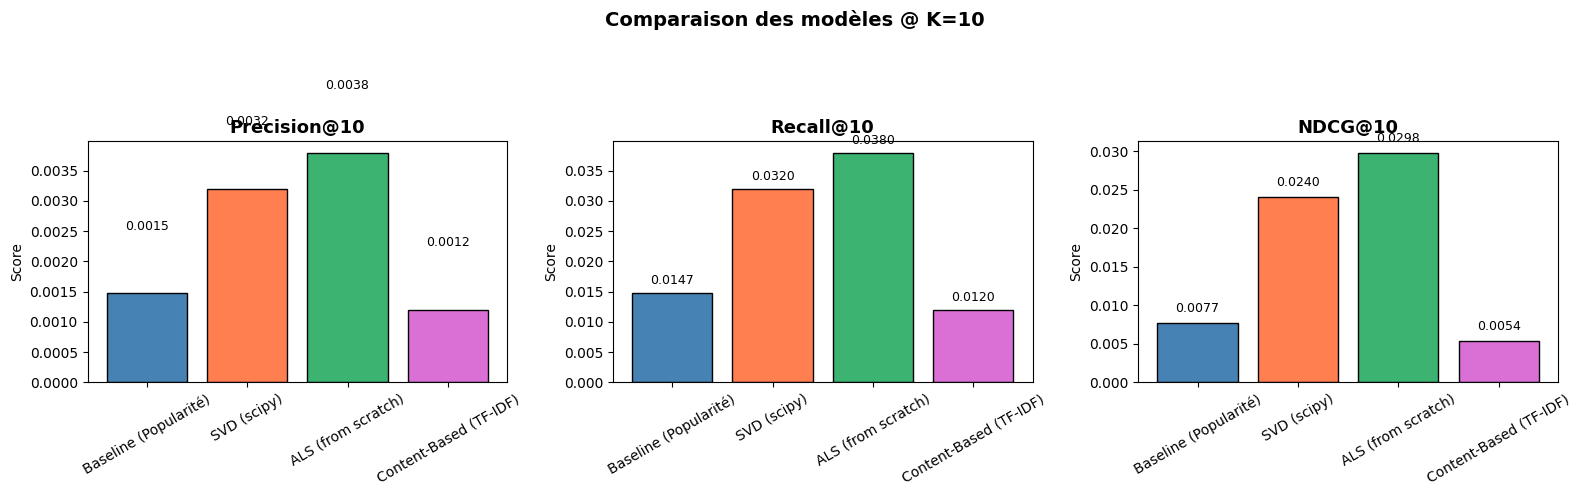

✅ Figure sauvegardée → models/model_comparison.png


In [27]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = [f'Precision@{K}', f'Recall@{K}', f'NDCG@{K}']
colors  = ['steelblue', 'coral', 'mediumseagreen', 'orchid']

for ax, metric in zip(axes, metrics):
    values = [results_all[m].get(metric, 0) for m in results_all]
    bars   = ax.bar(list(results_all.keys()), values, color=colors, edgecolor='black')
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylabel('Score')
    ax.tick_params(axis='x', rotation=30)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)

plt.suptitle(f'Comparaison des modèles @ K={K}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(MODELS_DIR / 'model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figure sauvegardée → models/model_comparison.png')

## 11. Tuning des hyperparamètres — SVD & ALS

On cherche les meilleurs hyperparamètres via une grid search manuelle sur le NDCG@10.

In [28]:
# ── 11.1 Tuning SVD : nombre de facteurs latents ───────────────────────────
print('🔍 Tuning SVD — K_FACTORS...')
svd_results = []

for k_factors in [20, 50, 100, 150]:
    U_, sigma_, Vt_ = svds(csr_matrix(R_centered), k=k_factors)
    R_pred_ = np.dot(np.dot(U_, np.diag(sigma_)), Vt_) + user_mean[:, np.newaxis]

    def svd_tuned(user_id, n=10, _R=R_pred_):
        try:
            uidx = user_enc.transform([user_id])[0]
        except ValueError:
            return popular_items[:n]
        return item_enc.inverse_transform(np.argsort(_R[uidx])[::-1][:n]).tolist()

    res = evaluate_model(svd_tuned, test_sample, train_sample, k=K)
    svd_results.append({'k_factors': k_factors, **res})
    print(f'  k={k_factors:3d} → NDCG@10={res["NDCG@10"]:.4f} | Precision@10={res["Precision@10"]:.4f}')

svd_tune_df = pd.DataFrame(svd_results).set_index('k_factors')
best_k_svd  = svd_tune_df['NDCG@10'].idxmax()
print(f'\n✅ Meilleur K_FACTORS SVD : {best_k_svd}')

🔍 Tuning SVD — K_FACTORS...
  k= 20 → NDCG@10=0.0135 | Precision@10=0.0018
  k= 50 → NDCG@10=0.0240 | Precision@10=0.0032
  k=100 → NDCG@10=0.0270 | Precision@10=0.0036
  k=150 → NDCG@10=0.0325 | Precision@10=0.0038

✅ Meilleur K_FACTORS SVD : 150


In [29]:
# ── 11.2 Tuning ALS : n_factors × regularization ───────────────────────────
print('🔍 Tuning ALS — n_factors x regularization...')
als_results = []

param_grid = [
    {'n_factors': 16, 'reg': 0.01},
    {'n_factors': 32, 'reg': 0.01},
    {'n_factors': 32, 'reg': 0.1},
    {'n_factors': 64, 'reg': 0.1},
    {'n_factors': 64, 'reg': 0.5},
]

for params in param_grid:
    model_ = ALSRecommender(
        n_factors=params['n_factors'],
        n_iterations=8,
        alpha=40,
        regularization=params['reg'],
        random_state=RANDOM_STATE
    )
    model_.fit(user_item_matrix)

    def als_tuned(user_id, n=10, _m=model_):
        try:
            uidx = int(user_enc.transform([user_id])[0])
        except ValueError:
            return popular_items[:n]
        top = _m.recommend(uidx, n=n, filter_seen=seen_items_by_user.get(uidx, []))
        return item_enc.inverse_transform(top).tolist()

    res = evaluate_model(als_tuned, test_sample, train_sample, k=K)
    als_results.append({**params, **res})
    print(f"  factors={params['n_factors']:2d} reg={params['reg']:.2f} → "
          f"NDCG@10={res['NDCG@10']:.4f} | Precision@10={res['Precision@10']:.4f}")

als_tune_df  = pd.DataFrame(als_results)
best_als_row = als_tune_df.loc[als_tune_df['NDCG@10'].idxmax()]
print(f"\n✅ Meilleurs params ALS : n_factors={int(best_als_row['n_factors'])} | reg={best_als_row['reg']}")

🔍 Tuning ALS — n_factors x regularization...


ALS: 100%|██████████| 8/8 [00:01<00:00,  7.25it/s]


  factors=16 reg=0.01 → NDCG@10=0.0240 | Precision@10=0.0034


ALS: 100%|██████████| 8/8 [00:01<00:00,  5.86it/s]


  factors=32 reg=0.01 → NDCG@10=0.0277 | Precision@10=0.0038


ALS: 100%|██████████| 8/8 [00:01<00:00,  6.02it/s]


  factors=32 reg=0.10 → NDCG@10=0.0283 | Precision@10=0.0038


ALS: 100%|██████████| 8/8 [00:02<00:00,  3.76it/s]


  factors=64 reg=0.10 → NDCG@10=0.0248 | Precision@10=0.0030


ALS: 100%|██████████| 8/8 [00:02<00:00,  3.91it/s]


  factors=64 reg=0.50 → NDCG@10=0.0259 | Precision@10=0.0030

✅ Meilleurs params ALS : n_factors=32 | reg=0.1


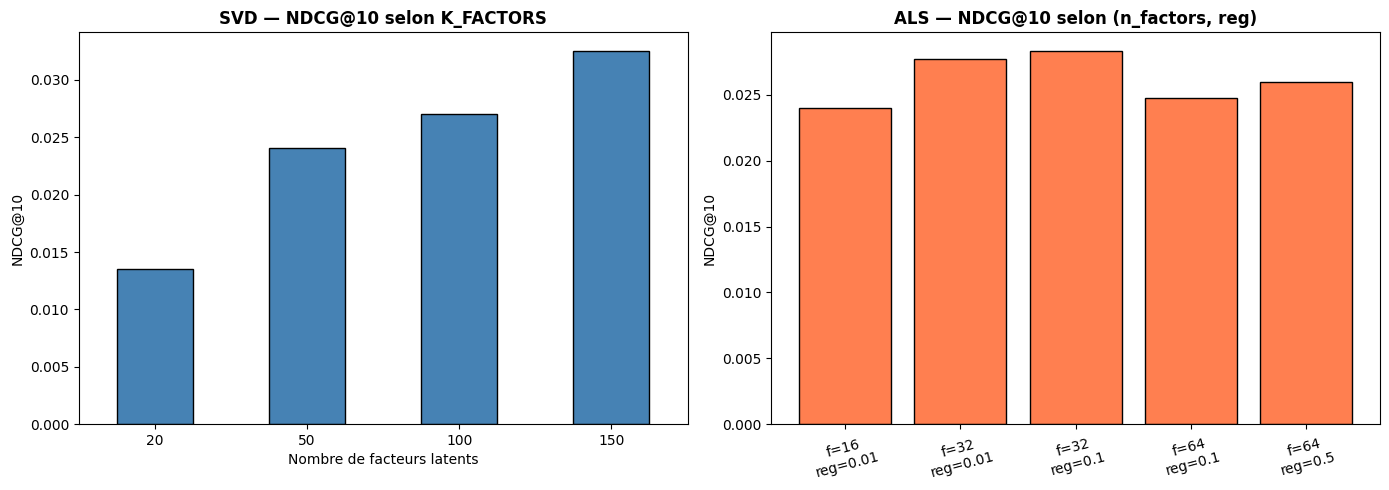

In [31]:
# ── 11.3 Visualisation du tuning ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

svd_tune_df['NDCG@10'].plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('SVD — NDCG@10 selon K_FACTORS', fontweight='bold')
axes[0].set_xlabel('Nombre de facteurs latents')
axes[0].set_ylabel('NDCG@10')
axes[0].tick_params(axis='x', rotation=0)

labels = [f"f={int(r['n_factors'])}\nreg={r['reg']}" for _, r in als_tune_df.iterrows()]
axes[1].bar(labels, als_tune_df['NDCG@10'], color='coral', edgecolor='black')
axes[1].set_title('ALS — NDCG@10 selon (n_factors, reg)', fontweight='bold')
axes[1].set_ylabel('NDCG@10')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig(MODELS_DIR / 'tuning_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [32]:
# ── 11.4 Réentraîner avec les meilleurs hyperparamètres ─────────────────────
U_best, sigma_best, Vt_best = svds(csr_matrix(R_centered), k=int(best_k_svd))
R_pred = np.dot(np.dot(U_best, np.diag(sigma_best)), Vt_best) + user_mean[:, np.newaxis]
print(f'✅ SVD réentraîné avec k={best_k_svd} facteurs')

als_model = ALSRecommender(
    n_factors=int(best_als_row['n_factors']),
    n_iterations=15,
    alpha=40,
    regularization=float(best_als_row['reg']),
    random_state=RANDOM_STATE
)
als_model.fit(user_item_matrix)
print(f"✅ ALS réentraîné avec n_factors={int(best_als_row['n_factors'])}, reg={best_als_row['reg']}")

results_svd = evaluate_model(svd_recommender, test_sample, train_sample, k=K)
results_als = evaluate_model(als_recommender, test_sample, train_sample, k=K)
print(f"\nAprès tuning → SVD NDCG@10={results_svd['NDCG@10']:.4f} | ALS NDCG@10={results_als['NDCG@10']:.4f}")

✅ SVD réentraîné avec k=150 facteurs


ALS: 100%|██████████| 15/15 [00:02<00:00,  6.29it/s]


✅ ALS réentraîné avec n_factors=32, reg=0.1

Après tuning → SVD NDCG@10=0.0325 | ALS NDCG@10=0.0321


## 12. Modèle 5 : Hybrid Recommender (SVD + Content-Based)

**Score hybride = α × score_SVD_normalisé + (1−α) × score_CB_normalisé**

On cherche le meilleur α par grid search.

In [33]:
# ── Normalisation SVD en [0,1] par user ────────────────────────────────────
R_pred_norm = R_pred.copy()
r_min = R_pred_norm.min(axis=1, keepdims=True)
r_max = R_pred_norm.max(axis=1, keepdims=True)
denom = r_max - r_min
denom[denom == 0] = 1
R_pred_norm = (R_pred_norm - r_min) / denom

# ── Scores Content-Based sur tous les items ────────────────────────────────
def get_cb_scores(user_id):
    """Retourne un vecteur normalisé de scores CB (taille N_ITEMS) pour un user."""
    user_items = train_df[train_df['user_id'] == user_id]['item_id'].tolist()
    user_items = [i for i in user_items if i in item_to_idx]
    if not user_items:
        return None
    scores_cb = np.zeros(len(products_cb))
    for item_id in user_items:
        scores_cb += cosine_sim[item_to_idx[item_id]]
    # Mapper vers l'espace item_enc
    full_scores = np.zeros(N_ITEMS)
    for cb_idx, pid in idx_to_item.items():
        try:
            full_scores[int(item_enc.transform([pid])[0])] = scores_cb[cb_idx]
        except ValueError:
            pass
    s_min, s_max = full_scores.min(), full_scores.max()
    if s_max > s_min:
        full_scores = (full_scores - s_min) / (s_max - s_min)
    return full_scores

print('✅ Normalisation définie')

✅ Normalisation définie


In [34]:
# ── Grid search sur alpha ────────────────────────────────────────────────────
print('🔍 Recherche du meilleur alpha (poids SVD vs Content-Based)...')
alphas       = [0.0, 0.2, 0.4, 0.5, 0.6, 0.8, 1.0]
alpha_results = []

for alpha in alphas:
    def hybrid_recommender(user_id, n=10, _alpha=alpha):
        try:
            user_idx = int(user_enc.transform([user_id])[0])
        except ValueError:
            return popular_items[:n]
        svd_scores = R_pred_norm[user_idx]
        cb_scores  = get_cb_scores(user_id)
        hybrid_scores = svd_scores if cb_scores is None else _alpha * svd_scores + (1 - _alpha) * cb_scores
        return item_enc.inverse_transform(np.argsort(hybrid_scores)[::-1][:n]).tolist()

    res = evaluate_model(hybrid_recommender, test_sample, train_sample, k=K)
    alpha_results.append({'alpha': alpha, **res})
    print(f"  alpha={alpha:.1f} → NDCG@10={res['NDCG@10']:.4f} | "
          f"Precision@10={res['Precision@10']:.4f} | Recall@10={res['Recall@10']:.4f}")

alpha_df   = pd.DataFrame(alpha_results)
best_alpha = float(alpha_df.loc[alpha_df['NDCG@10'].idxmax(), 'alpha'])
print(f'\n✅ Meilleur alpha : {best_alpha}')

🔍 Recherche du meilleur alpha (poids SVD vs Content-Based)...
  alpha=0.0 → NDCG@10=0.0067 | Precision@10=0.0014 | Recall@10=0.0140
  alpha=0.2 → NDCG@10=0.0212 | Precision@10=0.0036 | Recall@10=0.0360
  alpha=0.4 → NDCG@10=0.0299 | Precision@10=0.0038 | Recall@10=0.0380
  alpha=0.5 → NDCG@10=0.0306 | Precision@10=0.0036 | Recall@10=0.0360
  alpha=0.6 → NDCG@10=0.0299 | Precision@10=0.0036 | Recall@10=0.0360
  alpha=0.8 → NDCG@10=0.0273 | Precision@10=0.0028 | Recall@10=0.0280
  alpha=1.0 → NDCG@10=0.0325 | Precision@10=0.0038 | Recall@10=0.0380

✅ Meilleur alpha : 1.0


In [35]:
# ── Modèle hybride final ────────────────────────────────────────────────────
def hybrid_final(user_id, n=10):
    """Hybride SVD + Content-Based avec le meilleur alpha."""
    try:
        user_idx = int(user_enc.transform([user_id])[0])
    except ValueError:
        return popular_items[:n]
    svd_scores    = R_pred_norm[user_idx]
    cb_scores     = get_cb_scores(user_id)
    hybrid_scores = svd_scores if cb_scores is None else best_alpha * svd_scores + (1 - best_alpha) * cb_scores
    return item_enc.inverse_transform(np.argsort(hybrid_scores)[::-1][:n]).tolist()

results_hybrid = evaluate_model(hybrid_final, test_sample, train_sample, k=K)
print(f'📊 Hybride (alpha={best_alpha}) :')
for metric, value in results_hybrid.items():
    print(f'  {metric}: {value:.4f}' if isinstance(value, float) else f'  {metric}: {value}')

📊 Hybride (alpha=1.0) :
  Precision@10: 0.0038
  Recall@10: 0.0380
  NDCG@10: 0.0325
  n_users_eval: 500



📊 Comparaison finale (tous modèles) :


,Precision@10,Recall@10,NDCG@10
Baseline (Popularité),0.001473,0.014726,0.007694
SVD (scipy),0.003200,0.032000,0.024045
ALS (from scratch),0.003800,0.038000,0.029829
Content-Based (TF-IDF),0.001200,0.012000,0.005399
Hybride (SVD + CB),0.003800,0.038000,0.032524


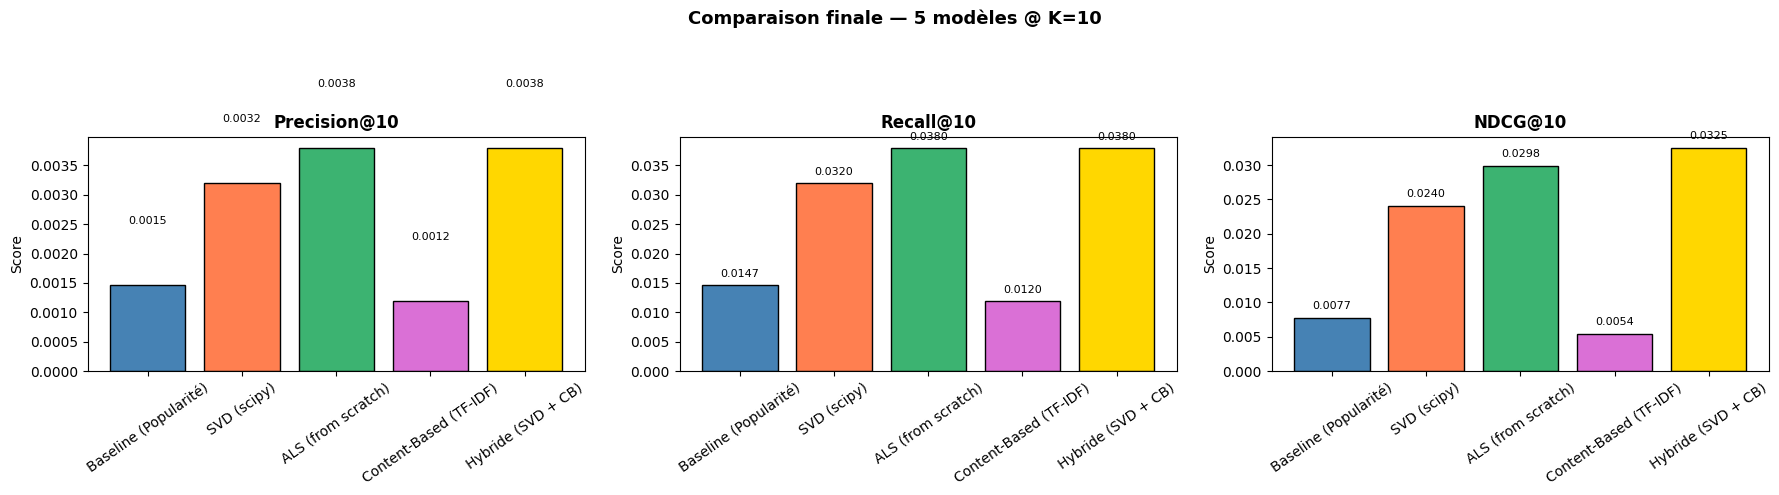

In [36]:
# ── Comparaison finale avec le modèle hybride ───────────────────────────────
results_all['Hybride (SVD + CB)'] = results_hybrid

results_final = pd.DataFrame(results_all).T.drop(columns=['n_users_eval'])
print('\n📊 Comparaison finale (tous modèles) :')
display(results_final.style.highlight_max(axis=0, color='lightgreen'))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors_ext   = ['steelblue', 'coral', 'mediumseagreen', 'orchid', 'gold']
metrics_list = [f'Precision@{K}', f'Recall@{K}', f'NDCG@{K}']

for ax, metric in zip(axes, metrics_list):
    values = [results_all[m].get(metric, 0) for m in results_all]
    bars   = ax.bar(list(results_all.keys()), values, color=colors_ext, edgecolor='black')
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylabel('Score')
    ax.tick_params(axis='x', rotation=35)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{val:.4f}', ha='center', va='bottom', fontsize=8)

plt.suptitle(f'Comparaison finale — 5 modèles @ K={K}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(MODELS_DIR / 'final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Analyse des recommandations

In [37]:
# User avec le plus d'achats
sample_user = train_df.groupby('user_id').size().sort_values(ascending=False).index[0]

print(f'👤 User : {sample_user}')
user_history = (
    train_df[train_df['user_id'] == sample_user]
    .merge(products_full[['product_id', 'product_category_name_english']],
           left_on='item_id', right_on='product_id', how='left')
)
display(user_history[['item_id', 'product_category_name_english', 'rating']].head(10))

👤 User : fc3d1daec319d62d49bfb5e1f83123e9


,item_id,product_category_name_english,rating
0,270516a3f41dc035aa87d220228f844c,health_beauty,1.0
1,05b515fdc76e888aada3c6d66c201dff,health_beauty,1.0
2,05b515fdc76e888aada3c6d66c201dff,health_beauty,1.0
3,05b515fdc76e888aada3c6d66c201dff,health_beauty,1.0
4,05b515fdc76e888aada3c6d66c201dff,health_beauty,1.0
5,05b515fdc76e888aada3c6d66c201dff,health_beauty,1.0
6,05b515fdc76e888aada3c6d66c201dff,health_beauty,1.0
7,05b515fdc76e888aada3c6d66c201dff,health_beauty,1.0
8,05b515fdc76e888aada3c6d66c201dff,health_beauty,1.0
9,05b515fdc76e888aada3c6d66c201dff,health_beauty,1.0


In [38]:
def show_recommendations(user_id, recommender_fn, name, n=10):
    reco_ids = recommender_fn(user_id, n)
    reco_df  = pd.DataFrame({'product_id': reco_ids})
    reco_df  = reco_df.merge(
        products_full[['product_id', 'product_category_name_english']],
        on='product_id', how='left'
    )
    reco_df.insert(0, 'rank', range(1, len(reco_df) + 1))
    print(f'\n🎯 Recommandations [{name}] :')
    display(reco_df)

show_recommendations(sample_user, popularity_recommender,    'Popularité')
show_recommendations(sample_user, svd_recommender,           'SVD')
show_recommendations(sample_user, als_recommender,           'ALS')
show_recommendations(sample_user, content_based_recommender, 'Content-Based')


🎯 Recommandations [Popularité] :


,rank,product_id,product_category_name_english
0,1,422879e10f46682990de24d770e7f83d,garden_tools
1,2,368c6c730842d78016ad823897a372db,garden_tools
2,3,53759a2ecddad2bb87a079a1f1519f73,garden_tools
3,4,aca2eb7d00ea1a7b8ebd4e68314663af,furniture_decor
4,5,389d119b48cf3043d311335e499d9c6b,garden_tools
5,6,b532349fe46b38fbc7bb3914c1bdae07,furniture_decor
6,7,a62e25e09e05e6faf31d90c6ec1aa3d1,watches_gifts
7,8,eb8c629f70275fd1c4f809116cce1efc,furniture_decor
8,9,e53e557d5a159f5aa2c5e995dfdf244b,computers_accessories
9,10,9ecadb84c81da840dbf3564378b586e9,furniture_decor



🎯 Recommandations [SVD] :


,rank,product_id,product_category_name_english
0,1,f3ce47ccf98da2906f6b8b1387618e07,housewares
1,2,cac52d956eff0cacf32f4b0f0f3aac5c,housewares
2,3,19421075ae0b585f2dc13ff149e2119d,sports_leisure
3,4,03e1c946c0ddfc58724ff262aef08dff,housewares
4,5,2fb9e46750ac55362f7b642f12b5835b,computers_accessories
5,6,5d6bea33648f018dbb563f3a2fab09f3,furniture_decor
6,7,cf1d8e226162a1d0ad61f29b7ed72d82,market_place
7,8,70c1bce00b24bfd21332f7f8ebe2217f,housewares
8,9,6b61c9889ff5ea54a786b54fff36251f,computers_accessories
9,10,b532349fe46b38fbc7bb3914c1bdae07,furniture_decor



🎯 Recommandations [ALS] :


,rank,product_id,product_category_name_english
0,1,a6ad77b15e566298a4e8ee2011ab1255,furniture_decor
1,2,8ed094bfe076c568f6bb10feada3f75d,office_furniture
2,3,bdc3291ab242ec1effc8eb0987850268,electronics
3,4,a659cb33082b851fb87a33af8f0fff29,auto
4,5,b623b7cb05ee3248fbe4a6ecbeed79a4,toys
5,6,781afe929e3016a667f5f439afd55fce,sports_leisure
6,7,154e7e31ebfa092203795c972e5804a6,health_beauty
7,8,8b50a72d52d7a91fb19d19fbe069e2f2,housewares
8,9,1a428b685ede76217c9efb550c4aaa59,bed_bath_table
9,10,e53e557d5a159f5aa2c5e995dfdf244b,computers_accessories



🎯 Recommandations [Content-Based] :


,rank,product_id,product_category_name_english
0,1,b81a05d0dd312ece2140846909f5ef81,furniture_decor
1,2,c33af1c0bec994ff07664ab6dcae7a86,furniture_decor
2,3,ec2d43cc59763ec91694573b31f1c29a,bed_bath_table
3,4,553e0e7590d3116a072507a3635d2877,bed_bath_table
4,5,f4041d76285c2a34ad5013e8d287a400,bed_bath_table
5,6,7340a3839a1de1e99d149b8cf052a2ec,bed_bath_table
6,7,d1859a58e608b68f4066e0c77e526ef1,bed_bath_table
7,8,b7d94dc0640c7025dc8e3b46b52d8239,computers_accessories
8,9,dc9471db933efad7bf0ce685380578bd,computers_accessories
9,10,3ce943997ff85cad84ec6770b35d6bcd,computers_accessories


## 14. Sauvegarde finale & résumé

In [39]:
# Encodeurs
with open(MODELS_DIR / 'user_encoder.pkl', 'wb') as f:
    pickle.dump(user_enc, f)
with open(MODELS_DIR / 'item_encoder.pkl', 'wb') as f:
    pickle.dump(item_enc, f)

# Content-based
with open(MODELS_DIR / 'cosine_sim.pkl', 'wb') as f:
    pickle.dump((cosine_sim, item_to_idx, idx_to_item), f)

# Popularité
with open(MODELS_DIR / 'popular_items.pkl', 'wb') as f:
    pickle.dump(popular_items, f)

# Résumé JSON
summary = {
    'dataset'        : 'MEL Cameroun E-Commerce',
    'python_version' : '3.13+',
    'n_users'        : N_USERS,
    'n_items'        : N_ITEMS,
    'n_interactions' : int(len(df_filtered)),
    'K'              : K,
    'best_svd_k_factors' : int(best_k_svd),
    'best_als_n_factors' : int(best_als_row['n_factors']),
    'best_als_reg'       : float(best_als_row['reg']),
    'best_hybrid_alpha'  : best_alpha,
    'results': {
        model: {k: round(v, 4) for k, v in res.items() if isinstance(v, float)}
        for model, res in results_all.items()
    }
}
with open(MODELS_DIR / 'results_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print('✅ Tous les artefacts sauvegardés dans models/')
print('\n📋 Résumé final :')
print(json.dumps(summary, indent=2))

✅ Tous les artefacts sauvegardés dans models/

📋 Résumé final :
{
  "dataset": "MEL Cameroun E-Commerce",
  "python_version": "3.13+",
  "n_users": 3599,
  "n_items": 882,
  "n_interactions": 9657,
  "K": 10,
  "best_svd_k_factors": 150,
  "best_als_n_factors": 32,
  "best_als_reg": 0.1,
  "best_hybrid_alpha": 1.0,
  "results": {
    "Baseline (Popularit\u00e9)": {
      "Precision@10": 0.0015,
      "Recall@10": 0.0147,
      "NDCG@10": 0.0077
    },
    "SVD (scipy)": {
      "Precision@10": 0.0032,
      "Recall@10": 0.032,
      "NDCG@10": 0.024
    },
    "ALS (from scratch)": {
      "Precision@10": 0.0038,
      "Recall@10": 0.038,
      "NDCG@10": 0.0298
    },
    "Content-Based (TF-IDF)": {
      "Precision@10": 0.0012,
      "Recall@10": 0.012,
      "NDCG@10": 0.0054
    },
    "Hybride (SVD + CB)": {
      "Precision@10": 0.0038,
      "Recall@10": 0.038,
      "NDCG@10": 0.0325
    }
  }
}
